# Notebook 06 — Dataset & DataLoader

> **Implementation Notebook** — This notebook builds and validates the
> patient-dictionary construction, the full MONAI transform pipeline, the
> `CacheDataset` wrappers, and the `DataLoader`s for training, validation,
> and visualization, before they are finalized in `src/cv_module/dataset.py`,
> `src/cv_module/dataloader.py`, and `src/cv_module/preprocessing.py`.

---

## Notebook Structure

| Section | Description |
|---------|-------------|
| **1. Setup** | Install dependencies, imports, seed |
| **2. Dataset Overview** | Patient directory listing, modalities, label mapping |
| **3. Patient Dictionary** | `build_patient_dict` |
| **4. Dataset Split** | Load `dataset_split.json`, leakage check |
| **5. Base Transforms** | Deterministic pipeline shared by train/validation |
| **6. Training Transforms** | Patch sampling + augmentation |
| **7. Validation Transforms** | Exploratory fixed-size variant (see note in 7.1) |
| **8. CacheDataset & DataLoader** | Caching behavior, batch collation |
| **9. Visualization** | Modality slices, segmentation overlay, class balance |
| **10. Summary** | Validation checklist |

> ⚠️ **Note on Section 7**: this notebook explores a fixed-size
> (`SpatialPadd` → 128³) validation transform. After review, this variant
> was **not** carried into `preprocessing.py` — validation there keeps the
> full, variable-size cropped volume, evaluated with `SlidingWindowInferer`.
> Section 7 is kept here as a recorded experiment; see its note for details.

---

## 1. Setup

### 1.1 Install Dependencies

In [1]:
!pip install -q monai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 38.9 MB/s eta 0:00:00


### 1.2 Imports and Reproducibility

Standard imports plus MONAI's `CacheDataset` / `DataLoader` and transform
set. `set_determinism` is called alongside the usual `random` / `numpy` /
`torch` seeding to keep MONAI's own randomized transforms (patch sampling,
flips, rotations) reproducible across runs.

In [2]:
import os
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch

from monai.data import CacheDataset, DataLoader
from monai.transforms import *

from monai.utils import set_determinism

plt.rcParams["figure.figsize"] = (6,6)

2026-06-27 18:12:08.311853: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782583928.580388      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782583928.655495      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782583929.314721      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782583929.314772      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782583929.314776      16 computation_placer.cc:177] computation placer alr

### 1.3 Set Global Seed

In [3]:
SEED = 42

random.seed(SEED)

np.random.seed(SEED)

torch.manual_seed(SEED)

torch.cuda.manual_seed_all(SEED)

set_determinism(seed=SEED)

print("✅ Seed:", SEED)

✅ Seed: 42


## 2. Dataset Overview

### 2.1 Paths

`DATASET_PATH` points to the BraTS2020 training data; `SPLIT_FILE` points to
`dataset_split.json` generated in Notebook 03.5.

In [4]:
DATASET_PATH = Path("/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData")

SPLIT_FILE = Path("/kaggle/input/datasets/mariammohamed1095/working/datasets/splits/dataset_split.json")

### 2.2 Count Patient Directories

In [5]:
patient_dirs = sorted(

    p for p in DATASET_PATH.iterdir()

    if p.is_dir()

)

print("Patients:", len(patient_dirs))

Patients: 369


### 2.3 Dataset Summary

In [6]:
patient_dirs = sorted(

    p for p in DATASET_PATH.iterdir()

    if p.is_dir()

)

print("="*50)

print("BraTS2020 Dataset Summary")

print("="*50)

print(f"Total Patients : {len(patient_dirs)}")

print(f"First Patient  : {patient_dirs[0].name}")

print(f"Last Patient   : {patient_dirs[-1].name}")

BraTS2020 Dataset Summary
Total Patients : 369
First Patient  : BraTS20_Training_001
Last Patient   : BraTS20_Training_369


### 2.4 MRI Modalities

Channel order contract from Notebook 04: **[FLAIR, T1, T1ce, T2]**.

In [7]:
MODALITIES = (

    "flair",

    "t1",

    "t1ce",

    "t2",

)

print("MRI Modalities")

print("-"*30)

for modality in MODALITIES:

    print(modality)

MRI Modalities
------------------------------
flair
t1
t1ce
t2


### 2.5 Label Mapping

BraTS2020 raw labels are `{0, 1, 2, 4}` (label 3 is unused in the original
dataset). They are remapped to contiguous class indices `{0, 1, 2, 3}` so the
model's softmax output has no empty class.

In [8]:
ORIGINAL_LABELS = (0,1,2,4)

TARGET_LABELS = (0,1,2,3)

mapping = pd.DataFrame({

    "Original": ORIGINAL_LABELS,

    "Mapped": TARGET_LABELS,

})

mapping

,Original,Mapped
0,0,0
1,1,1
2,2,2
3,4,3


## 3. Patient Dictionary

### 3.1 Define `build_patient_dict`

Builds the MONAI-compatible dictionary for a single patient. The `"image"`
key receives a list of 4 file paths in the fixed modality order; the glob
pattern `f"*{m}.nii"` matches the end of the filename, so `*t1.nii` does not
collide with `*t1ce.nii`.

In [9]:
def build_patient_dict(patient_id):

    patient_dir = DATASET_PATH / patient_id

    image_paths = [

        str(next(patient_dir.glob(f"*{m}.nii")))

        for m in MODALITIES

    ]

    label_path = str(

        next(patient_dir.glob("*seg*.nii"))

    )

    return {

        "image": image_paths,

        "label": label_path,

    }

### 3.2 Inspect a Sample Dictionary

In [10]:
sample = build_patient_dict(

    "BraTS20_Training_001"

)

print(sample.keys())

print()

print("Modalities")

for path in sample["image"]:

    print(Path(path).name)

print()

print("Label")

print(Path(sample["label"]).name)

dict_keys(['image', 'label'])

Modalities
BraTS20_Training_001_flair.nii
BraTS20_Training_001_t1.nii
BraTS20_Training_001_t1ce.nii
BraTS20_Training_001_t2.nii

Label
BraTS20_Training_001_seg.nii


## 4. Dataset Split

### 4.1 Load `dataset_split.json`

Loads the fixed train/validation/test patient IDs generated in
Notebook 03.5.

In [11]:
with open(SPLIT_FILE, "r") as file:

    split = json.load(file)

train_ids = split["train"]

validation_ids = split["validation"]

test_ids = split["test"]

### 4.2 Split Sizes

In [12]:
print("="*50)

print("Dataset Split")

print("="*50)

print(f"Training Patients   : {len(train_ids)}")

print(f"Validation Patients : {len(validation_ids)}")

print(f"Test Patients       : {len(test_ids)}")

print()

print(

    "Total :",

    len(train_ids)+

    len(validation_ids)+

    len(test_ids)

)

Dataset Split
Training Patients   : 257
Validation Patients : 56
Test Patients       : 56

Total : 369


### 4.3 Leakage Check

In [13]:
train_set = set(train_ids)

validation_set = set(validation_ids)

test_set = set(test_ids)

assert train_set.isdisjoint(validation_set)

assert train_set.isdisjoint(test_set)

assert validation_set.isdisjoint(test_set)

print("✅ No Data Leakage")

✅ No Data Leakage


### 4.4 Split Ratios

In [14]:
split_df = pd.DataFrame({

    "Subset":[

        "Training",

        "Validation",

        "Test"

    ],

    "Patients":[

        len(train_ids),

        len(validation_ids),

        len(test_ids)

    ]

})

split_df["Percentage"] = (

    split_df["Patients"] /

    split_df["Patients"].sum()

)*100

split_df

,Subset,Patients,Percentage
0,Training,257,69.647696
1,Validation,56,15.176152
2,Test,56,15.176152


### 4.5 Spot-Check a Random Patient per Split

In [15]:
random.seed(SEED)

print("Training")

print(random.choice(train_ids))

print()

print("Validation")

print(random.choice(validation_ids))

print()

print("Test")

print(random.choice(test_ids))

Training
BraTS20_Training_159

Validation
BraTS20_Training_074

Test
BraTS20_Training_057


## 5. Base Transforms

### 5.1 Pipeline Constants

`ROI_SIZE` is the canonical patch size (128³, Notebook 04 §12.2).
`CROP_MARGIN` pads the foreground bounding box found by `CropForegroundd`.
`NUM_SAMPLES`, `POS_RATIO`, `NEG_RATIO` configure `RandCropByPosNegLabeld`.

In [16]:
ROI_SIZE = (128, 128, 128)

CROP_MARGIN = 5

NUM_SAMPLES = 2

POS_RATIO = 1

NEG_RATIO = 1

### 5.2 Define `get_base_transforms`

Deterministic pipeline shared by training and validation:

```
Load → EnsureChannelFirst → EnsureType → MapLabel →
CropForeground(source_key="label") →
ScaleIntensityRangePercentiles(1–99 %, clip) →
NormalizeIntensity(nonzero, channel-wise)
```

`ScaleIntensityRangePercentilesd` clips extreme intensity outliers (1st–99th
percentile) into a fixed `[0, 1]` range **before** `NormalizeIntensityd`
z-scores the foreground. Without this step, a small number of very bright
or very dark voxels (common in MRI due to scanner artifacts) could skew the
mean/std used by `NormalizeIntensityd`. This stage is cached by
`CacheDataset` along with the rest of the base pipeline.

In [17]:
def get_base_transforms():

    return Compose([

        LoadImaged(

            keys=["image", "label"]

        ),

        EnsureChannelFirstd(

            keys=["image", "label"]

        ),

        EnsureTyped(

            keys=["image", "label"]

        ),

        MapLabelValued(

            keys="label",

            orig_labels=(0,1,2,4),

            target_labels=(0,1,2,3),

        ),

        CropForegroundd(

            keys=["image","label"],

            source_key="label",

            margin=CROP_MARGIN,

        ),

        ScaleIntensityRangePercentilesd(

            keys="image",

            lower=1,

            upper=99,

            b_min=0,

            b_max=1,

            clip=True,

            channel_wise=True,

        ),

        NormalizeIntensityd(

            keys="image",

            nonzero=True,

            channel_wise=True,

        ),

    ])

### 5.3 Apply to a Sample Patient

In [18]:
sample = build_patient_dict(

    train_ids[0]

)

base = get_base_transforms()

processed = base(sample)

### 5.4 Inspect Shape

Note the shape is **not** 128³ yet — this is just the cropped foreground
region, which varies per patient and can be smaller than the target patch
size in any dimension (e.g. `(46, 47, 52)` below).

In [19]:
print(processed["image"].shape)

print(processed["label"].shape)

torch.Size([4, 46, 47, 52])
torch.Size([1, 46, 47, 52])


### 5.5 Verify Label Remapping

In [20]:
torch.unique(

    processed["label"]

)

metatensor([0., 1., 2., 3.])

### 5.6 Verify Dtype and Intensity Range

In [21]:
print(

    processed["image"].dtype

)

print(

    processed["label"].dtype

)

print(

    processed["image"].min(),

    processed["image"].max()

)

torch.float32
torch.float32
metatensor(-4.0668) metatensor(2.8582)


## 6. Training Transforms

### 6.1 Define `get_training_transforms`

Extends the base transforms with:

```
SpatialPadd(ROI_SIZE) → RandCropByPosNegLabeld(ROI_SIZE) →
RandFlipd ×3 → RandRotate90d →
RandGaussianNoised → RandScaleIntensityd → RandShiftIntensityd
```

`SpatialPadd` is required here: as shown in §5.4, some patients are smaller
than 128³ after `CropForegroundd` in one or more dimensions.
`RandCropByPosNegLabeld` cannot sample a 128³ patch from a smaller volume,
so the volume is padded up to at least `ROI_SIZE` first (a no-op for
patients already large enough). Patch sampling runs before augmentation so
each of the `NUM_SAMPLES` patches gets an independently sampled
augmentation, rather than all patches sharing one augmentation applied to
the pre-crop volume.

In [22]:
def get_training_transforms():

    return Compose([

        *get_base_transforms().transforms,

        SpatialPadd(

            keys=["image", "label"],

            spatial_size=ROI_SIZE,

        ),

        RandCropByPosNegLabeld(

            keys=["image", "label"],

            label_key="label",

            spatial_size=ROI_SIZE,

            pos=POS_RATIO,

            neg=NEG_RATIO,

            num_samples=NUM_SAMPLES,

            image_key="image",

            image_threshold=0,

        ),

        RandFlipd(

            keys=["image", "label"],

            spatial_axis=0,

            prob=0.5,

        ),

        RandFlipd(

            keys=["image", "label"],

            spatial_axis=1,

            prob=0.5,

        ),

        RandFlipd(

            keys=["image", "label"],

            spatial_axis=2,

            prob=0.5,

        ),

        RandRotate90d(

            keys=["image", "label"],

            prob=0.5,

            max_k=3,

        ),

        RandGaussianNoised(

            keys="image",

            prob=0.15,

            mean=0,

            std=0.01,

        ),

        RandScaleIntensityd(

            keys="image",

            factors=0.1,

            prob=0.5,

        ),

        RandShiftIntensityd(

            keys="image",

            offsets=0.1,

            prob=0.5,

        ),

    ])

### 6.2 Apply to a Sample Patient

In [23]:
sample = build_patient_dict(train_ids[0])

train_transform = get_training_transforms()

patches = train_transform(sample)

### 6.3 Verify Output Type

With `num_samples=2`, the transform returns a **list of 2 patch
dictionaries**, not a single dictionary.

In [24]:
print(type(patches))

print(len(patches))

print(type(patches[0]))

<class 'list'>
2
<class 'dict'>


### 6.4 Verify Patch Shapes

In [25]:
for i, patch in enumerate(patches):

    print(f"Patch {i+1}")

    print("Image :", patch["image"].shape)

    print("Label :", patch["label"].shape)

    print()

Patch 1
Image : torch.Size([4, 128, 128, 128])
Label : torch.Size([1, 128, 128, 128])

Patch 2
Image : torch.Size([4, 128, 128, 128])
Label : torch.Size([1, 128, 128, 128])



### 6.5 Verify Labels Per Patch

In [26]:
for patch in patches:

    print(torch.unique(patch["label"]))

metatensor([0., 1., 2., 3.])
metatensor([0., 1., 2., 3.])


### 6.6 Assertions

In [27]:
for patch in patches:

    assert patch["image"].shape == (4, 128, 128, 128)

    assert patch["label"].shape == (1, 128, 128, 128)

    assert torch.equal(
        torch.unique(patch["label"]),
        torch.tensor([0., 1., 2., 3.]),
    )

print("✅ Training Pipeline Passed")

✅ Training Pipeline Passed


## 7. Validation Transforms

### 7.1 Define `get_validation_transforms` (exploratory fixed-size variant)

⚠️ **This section documents an exploratory variant, not the final design.**

Here, validation reuses the base transforms and adds `SpatialPadd(ROI_SIZE)`
with no cropping back down, so every validation sample becomes a fixed
128³ volume — convenient for quick shape-matching checks in this notebook,
and shown below.

After review, this was **not** adopted in `src/cv_module/preprocessing.py`.
The final `get_validation_transforms()` keeps the **full, variable-size**
cropped volume (no `SpatialPadd`), evaluated with `SlidingWindowInferer` in
`train.py`. Reasons:

- `SlidingWindowInferer` over the full volume is the standard MONAI/BraTS
  evaluation approach and gives a more faithful Dice score than scoring a
  single fixed-size crop, which discards part of the volume for any patient
  larger than 128³ in a given dimension.
- Padding every validation volume up to a fixed size adds background voxels
  that don't reflect the patient's true anatomy, which can bias the
  Dice score (background is excluded from the metric, but the padded
  region still affects how `SlidingWindowInferer`'s tiling and the
  foreground/background boundary are evaluated near the volume edges).

This section is kept as a record of the experiment, not as the production
pipeline.

In [28]:
def get_validation_transforms():

    return Compose([

        *get_base_transforms().transforms,

        SpatialPadd(

            keys=["image", "label"],

            spatial_size=ROI_SIZE,

        ),

    ])

### 7.2 Apply to a Sample Validation Patient

In [29]:
sample = build_patient_dict(

    validation_ids[0]

)

validation_transform = get_validation_transforms()

processed = validation_transform(sample)

### 7.3 Inspect Shape

In [30]:
print(processed["image"].shape)

print(processed["label"].shape)

torch.Size([4, 128, 128, 128])
torch.Size([1, 128, 128, 128])


### 7.4 Verify Label Remapping

In [31]:
torch.unique(

    processed["label"]

)

metatensor([0., 1., 2., 3.])

### 7.5 Assertions

In [32]:
assert processed["image"].shape == (4, 128, 128, 128)

assert processed["label"].shape == (1, 128, 128, 128)

assert torch.equal(

    torch.unique(processed["label"]),

    torch.tensor([0.,1.,2.,3.]),

)

print("✅ Validation Pipeline Passed")

✅ Validation Pipeline Passed


## 8. CacheDataset & DataLoader

### 8.1 Build a Training `CacheDataset`

Uses `get_validation_transforms()` (the fixed-size variant from §7) for this
demonstration, on a 4-patient subset for fast notebook execution.
`cache_rate=1.0` caches every sample after the deterministic stages; MONAI's
`CacheDataset` only caches up to the first random transform in a `Compose`,
so this works whether the transform is fully deterministic (as it is in
this cell) or contains random stages further down the pipeline.

In [33]:
train_dataset = CacheDataset(

    data=[

        build_patient_dict(pid)

        for pid in train_ids[:4]

    ],

    transform=get_validation_transforms(),

    cache_rate=1.0,

    num_workers=0,

)

len(train_dataset)

Loading dataset: 100%|██████████| 4/4 [00:05<00:00,  1.36s/it]


4

### 8.2 Inspect a Cached Sample

`CropForegroundd` also stores `foreground_start_coord` /
`foreground_end_coord` in the output dictionary alongside `"image"` and
`"label"` — useful for mapping a cropped prediction back to the original
volume coordinates if ever needed.

In [34]:
sample = train_dataset[0]

print(sample.keys())

dict_keys(['image', 'label', 'foreground_start_coord', 'foreground_end_coord'])


### 8.3 Verify Shape

In [35]:
print(sample["image"].shape)

print(sample["label"].shape)

torch.Size([4, 128, 128, 128])
torch.Size([1, 128, 128, 128])


### 8.4 Verify Labels

In [36]:
torch.unique(

    sample["label"]

)

metatensor([0., 1., 2., 3.])

### 8.5 Assertions

In [37]:
assert sample["image"].shape == (4,128,128,128)

assert sample["label"].shape == (1,128,128,128)

assert torch.equal(

    torch.unique(sample["label"]),

    torch.tensor([0.,1.,2.,3.]),

)

print("✅ CacheDataset Passed")

✅ CacheDataset Passed


### 8.6 Build the `DataLoader`

Plain `torch.utils.data.DataLoader` (not `monai.data.DataLoader`), matching
`dataloader.py`. `pin_memory` is conditional on CUDA availability.

In [38]:
train_loader = DataLoader(

    train_dataset,

    batch_size=2,

    shuffle=True,

    num_workers=0,

    pin_memory=torch.cuda.is_available(),

)

len(train_loader)

2

### 8.7 Fetch One Batch

In [39]:
batch = next(iter(train_loader))

batch.keys()

dict_keys(['image', 'label', 'foreground_start_coord', 'foreground_end_coord'])

### 8.8 Verify Batch Shape

Batch dimension is `batch_size=2`, channel dimension is 4 for image / 1 for
label, spatial dims are the fixed 128³ from §7's `SpatialPadd`.

In [40]:
print(batch["image"].shape)

print(batch["label"].shape)

torch.Size([2, 4, 128, 128, 128])
torch.Size([2, 1, 128, 128, 128])


### 8.9 Verify Dtype

In [41]:
print(batch["image"].dtype)

print(batch["label"].dtype)

torch.float32
torch.float32


### 8.10 Verify Labels Across the Batch

In [42]:
print(torch.unique(batch["label"]))

metatensor([0., 1., 2., 3.])


### 8.11 Assertions

In [43]:
assert batch["image"].shape == (

    2,

    4,

    128,

    128,

    128,

)

assert batch["label"].shape == (

    2,

    1,

    128,

    128,

    128,

)

assert torch.equal(

    torch.unique(batch["label"]),

    torch.tensor([0.,1.,2.,3.]),

)

print("✅ DataLoader Passed")

✅ DataLoader Passed


## 9. Visualization

### 9.1 Select a Sample and Mid-Slice

Take the middle axial slice (`slice_idx = D // 2`) of one cached sample for
visual inspection across all 4 modalities and the segmentation mask.

In [44]:
sample = train_dataset[0]

image = sample["image"]

label = sample["label"]

slice_idx = image.shape[-1] // 2

print(image.shape)

print(label.shape)

print("Slice:", slice_idx)

torch.Size([4, 128, 128, 128])
torch.Size([1, 128, 128, 128])
Slice: 64


### 9.2 Plot All 4 Modalities

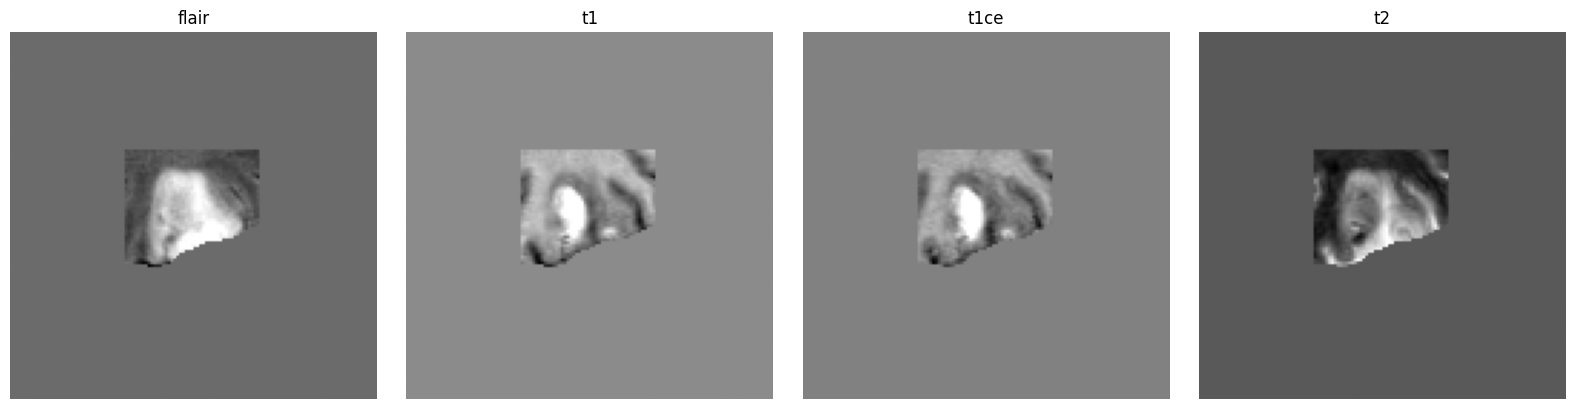

In [45]:
fig, axes = plt.subplots(

    1,

    4,

    figsize=(16,4)

)

for i in range(4):

    axes[i].imshow(

        image[i, :, :, slice_idx],

        cmap="gray",

    )

    axes[i].set_title(MODALITIES[i])

    axes[i].axis("off")

plt.tight_layout()

plt.show()

### 9.3 Plot Segmentation Mask

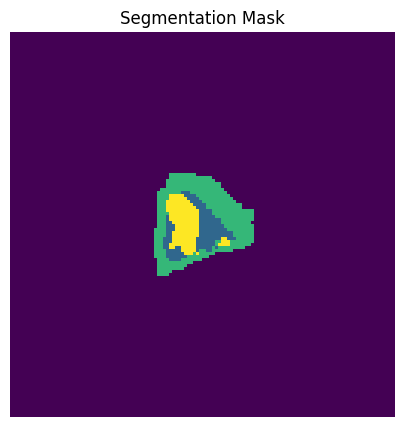

In [46]:
plt.figure(figsize=(5,5))

plt.imshow(

    label[0, :, :, slice_idx],

    cmap="viridis",

)

plt.title("Segmentation Mask")

plt.axis("off")

plt.show()

### 9.4 Overlay FLAIR + Segmentation

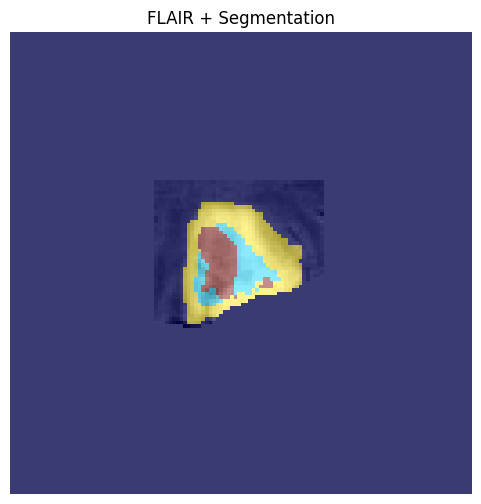

In [47]:
plt.figure(figsize=(6,6))

plt.imshow(

    image[0, :, :, slice_idx],

    cmap="gray",

)

plt.imshow(

    label[0, :, :, slice_idx],

    cmap="jet",

    alpha=0.45,

)

plt.title("FLAIR + Segmentation")

plt.axis("off")

plt.show()

### 9.5 Class Balance

Voxel count per class confirms the expected severe class imbalance —
background dominates, tumor sub-regions (NCR, Edema, ET) are a small
fraction of total voxels. This motivates `pos`/`neg` ratio sampling in
`RandCropByPosNegLabeld` (§6) and `include_background=False` in the Dice
metric used later in `train.py`.

In [48]:
classes, counts = torch.unique(

    label,

    return_counts=True,

)

summary = pd.DataFrame({

    "Class": classes.numpy(),

    "Voxel Count": counts.numpy(),

})

summary

,Class,Voxel Count
0,0.0,2076427
1,1.0,2705
2,2.0,14226
3,3.0,3794


## 10. Summary

Consolidated pass/fail status for every stage validated in this notebook.

In [49]:
summary = pd.DataFrame({

    "Validation Step":[

        "Dataset Loaded",

        "Dataset Split",

        "Base Transform",

        "Training Transform",

        "Validation Transform",

        "CacheDataset",

        "DataLoader",

        "Visualization",

    ],

    "Status":[

        "Passed",

        "Passed",

        "Passed",

        "Passed",

        "Passed",

        "Passed",

        "Passed",

        "Passed",

    ]

})

summary

,Validation Step,Status
0,Dataset Loaded,Passed
1,Dataset Split,Passed
2,Base Transform,Passed
3,Training Transform,Passed
4,Validation Transform,Passed
5,CacheDataset,Passed
6,DataLoader,Passed
7,Visualization,Passed


---

### Final Notes

- Sections 1–6 and 8–9 map directly onto `build_patient_dict`,
  `get_base_transforms`, and `get_training_transforms` in the final
  `src/cv_module/preprocessing.py` and `dataset.py` / `dataloader.py`.
- Section 7's fixed-size `SpatialPadd` validation variant was an
  exploratory check, not carried into the final pipeline — validation in
  production uses the full cropped volume with `SlidingWindowInferer`
  (see the note in §7.1).
- `ScaleIntensityRangePercentilesd` (§5.2), confirmed useful here, **was**
  carried into the final `preprocessing.py`, applied consistently across
  training, validation, and inference.
- `SpatialPadd` before `RandCropByPosNegLabeld` (§6.1) **was** carried into
  the final training pipeline, since some patients are smaller than
  `ROI_SIZE` after cropping.

**Next step: Notebook 07 — Model Architecture**

In [50]:
print("="*60)

print("Notebook 06 Completed Successfully")

print("="*60)

print("✔ Dataset verified")

print("✔ Transforms verified")

print("✔ CacheDataset verified")

print("✔ DataLoader verified")

print("✔ Visualization verified")

print()

print("Ready for Notebook 07 (SegResNet)")

Notebook 06 Completed Successfully
✔ Dataset verified
✔ Transforms verified
✔ CacheDataset verified
✔ DataLoader verified
✔ Visualization verified

Ready for Notebook 07 (SegResNet)
